In [15]:
import random
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [16]:
def generate_intervals(n):
    intervals = []
    for _ in range(n):
        start = random.randint(0, 10000)
        end = start + random.randint(1, 100)
        weight = random.randint(1, 100)
        intervals.append((start, end, weight))
    return intervals

In [17]:
def weighted_intervals(intervals):
    n = len(intervals)
    intervals.sort(key=lambda x: x[1])
    ends = [intervals[i][1] for i in range(n)]
    prev = [-1] * n
    for i in range(n):
        left = 0
        right = i - 1
        start = intervals[i][0]
        result = -1
        while left <= right:
            mid = (left + right) // 2
            if ends[mid] <= start:
                result = mid
                left = mid + 1
            else:
                right = mid - 1
        prev[i] = result
    maximum = [0] * n
    for i in range(n):
        include_weight = intervals[i][2]
        if prev[i] != -1:
            include_weight += maximum[prev[i]]
        exclude_weight = maximum[i-1] if i > 0 else 0
        maximum[i] = max(include_weight, exclude_weight)
    return maximum[n-1]

In [18]:
def measure_time(n, experiments=500):
    times = []
    for _ in range(experiments):
        intervals = generate_intervals(n)
        start = time.perf_counter()
        weighted_intervals(intervals)
        end = time.perf_counter()
        times.append(end - start)
    return np.array(times)

In [22]:
sizes = [3000, 7000, 9000, 10000, 15000, 20000, 30000]

means = []
stds = []

for n in sizes:
    times = measure_time(n)
    
    mean = np.mean(times)
    std = np.std(times)
    
    means.append(mean)
    stds.append(std)
    
    print(f"n = {n}")
    print(f"Мат. ожидание: {mean:.6f}")
    print(f"СКО: {std:.6f}")
    print()

n = 3000
Мат. ожидание: 0.008310
СКО: 0.003015

n = 7000
Мат. ожидание: 0.020140
СКО: 0.005041

n = 9000
Мат. ожидание: 0.025957
СКО: 0.001849

n = 10000
Мат. ожидание: 0.029352
СКО: 0.001586

n = 15000
Мат. ожидание: 0.046859
СКО: 0.002803

n = 20000
Мат. ожидание: 0.064493
СКО: 0.002818

n = 30000
Мат. ожидание: 2.458476
СКО: 52.566912



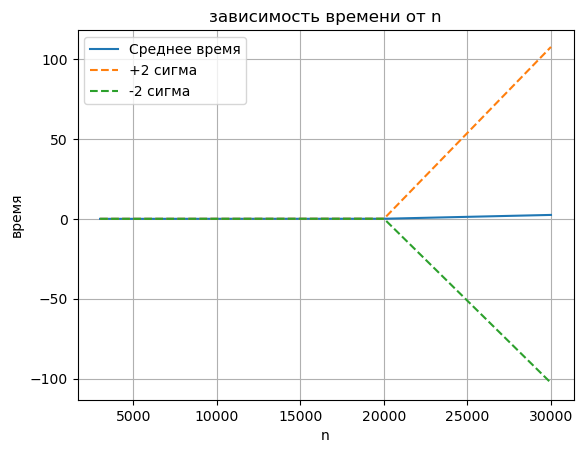

In [23]:
means = np.array(means)
stds = np.array(stds)
upper = means + 2 * stds
lower = means - 2 * stds

plt.plot(sizes, means, label='Среднее время')
plt.plot(sizes, upper, '--', label='+2 сигма')
plt.plot(sizes, lower, '--', label='-2 сигма')
plt.xlabel('n')
plt.ylabel('время')
plt.title('зависимость времени от n')
plt.legend()
plt.grid()
plt.show()

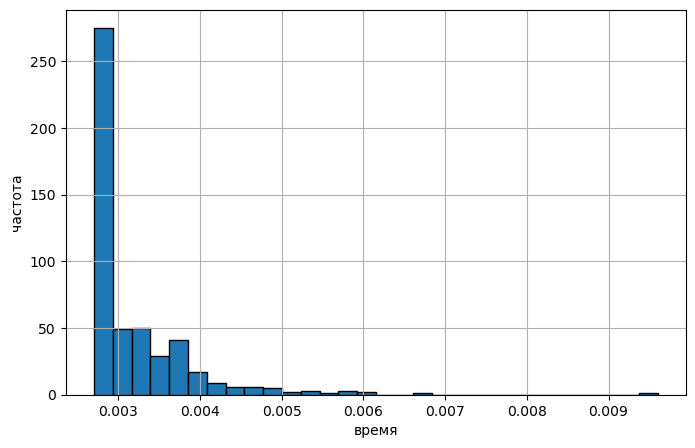

In [24]:
n = 1500
times = measure_time(n, experiments=500)

plt.figure(figsize=(8,5))
plt.hist(times, bins=30, edgecolor='black')
plt.xlabel('время')
plt.ylabel('частота')
plt.grid()
plt.show()

In [25]:
distributions = ['norm', 'expon', 'gamma', 'lognorm', 'uniform', 'laplace']

for dist_name in distributions:
    dist = getattr(stats, dist_name)
    params = dist.fit(times)
    ks_stat, p_value = stats.kstest(times, dist_name, args=params)
    print(f"{dist_name}: p-value = {p_value:.6f}")

norm: p-value = 0.000000
expon: p-value = 0.000000
gamma: p-value = 0.000000
lognorm: p-value = 0.000104
uniform: p-value = 0.000000
laplace: p-value = 0.000000


In [26]:
n = 1500
times = measure_time(n, experiments=500)

avg_time = np.mean(times)
min_time = np.min(times)
max_time = np.max(times)

print(f"Среднее время: {avg_time:.6f} сек")
print(f"Минимальное: {min_time:.6f} сек")
print(f"Максимальное: {max_time:.6f} сек")
print(f"Разброс: {max_time - min_time:.6f} сек")

if avg_time < 0.01:
    print('быстро')
elif avg_time < 0.05:
    print('хорошо')
elif avg_time < 0.1:
    print('сойдет')
else:
    print('медленно')

Среднее время: 0.003042 сек
Минимальное: 0.002710 сек
Максимальное: 0.005576 сек
Разброс: 0.002866 сек
быстро


In [27]:
print(f'n=100:  {means[0]:.6f} сек')
print(f'n=5000: {means[-1]:.6f} сек')

slowdown = means[-1] / means[0]
print(f'замедление в {slowdown:.1f} раз')

if slowdown < 100:
    print('эффективно')
else:
    print('неэффективно')

n=100:  0.008310 сек
n=5000: 2.458476 сек
замедление в 295.8 раз
неэффективно
